# Imports

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 120


# Data Loading and Visualization

In [2]:
def load_jsonl(path: Path) -> pd.DataFrame:
    """
    Load a newline-delimited JSON file where each line is a dict of features.
    Returns a pandas DataFrame with a datetime index based on 'time' (epoch seconds).
    """
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                records.append(obj)
            except json.JSONDecodeError:
                # Skip malformed lines
                continue

    if not records:
        raise ValueError(f"No valid JSON rows found in {path}")

    df = pd.DataFrame(records)

    if "time" not in df.columns:
        raise ValueError("Expected a 'time' field in each JSON row.")

    # Convert UNIX timestamp (seconds) to datetime and set as index
    df["timestamp"] = pd.to_datetime(df["time"], unit="s")
    df = df.set_index("timestamp").sort_index()

    return df


In [23]:
def load_jsonl(path: Path) -> pd.DataFrame:
    """
    Load a newline-delimited JSON file where each line is a dict of features.
    Returns a pandas DataFrame with a synthetic datetime index increasing by 1s per row.
    """
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                records.append(obj)
            except json.JSONDecodeError:
                # Skip malformed lines
                continue

    if not records:
        raise ValueError(f"No valid JSON rows found in {path}")

    df = pd.DataFrame(records)

    # --- CHANGE START ---
    # Instead of using the 'time' column, we generate a synthetic timeline.
    # We create a range from 0 to N seconds and convert to Datetime objects.
    # This creates a perfectly regular 1Hz signal (1 row = 1 second).
    df["timestamp"] = pd.to_datetime(range(len(df)), unit="s")
    
    df = df.set_index("timestamp")
    # --- CHANGE END ---

    return df


In [24]:
def add_eeg_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add derived EEG features:
      - Engagement (beta / (alpha + theta)) for Left/Right
      - Relaxation (alpha / (beta + gamma)) for Left/Right
      - Theta/Beta ratio for Left/Right
      - Fast/Slow activation index
      - Alpha and Beta asymmetry between hemispheres
      - Average engagement across hemispheres
      - Mean p_bad across hemispheres (if Left__p_bad and Right__p_bad exist)

    Assumes columns like:
      Left__alpha, Left__beta, Left__theta, Left__gamma, Left__delta,
      Right__alpha, Right__beta, Right__theta, Right__gamma, Right__delta, etc.
    """
    eps = 1e-9  # avoid division by zero

    for side in ["Left", "Right"]:
        a = df.get(f"{side}__alpha")
        b = df.get(f"{side}__beta")
        t = df.get(f"{side}__theta")
        g = df.get(f"{side}__gamma")
        d = df.get(f"{side}__delta")

        # Skip if any key band is missing
        if a is None or b is None or t is None or g is None or d is None:
            continue

        # Engagement: beta / (alpha + theta)
        df[f"{side}__engagement"] = b / (a + t + eps)

        # Relaxation: alpha / (beta + gamma)
        df[f"{side}__relaxation"] = a / (b + g + eps)

        # Theta/Beta ratio
        df[f"{side}__theta_beta_ratio"] = t / (b + eps)

        # Fast vs slow activation: (beta + gamma) / (delta + theta + alpha)
        df[f"{side}__activation_fast_slow"] = (b + g) / (d + t + a + eps)

    # Hemispheric asymmetry (log alpha / beta):
    # log(Right) - log(Left) → positive = right-dominant
    if all(col in df.columns for col in ["Left__alpha", "Right__alpha"]):
        df["Alpha_asymmetry"] = np.log(df["Right__alpha"] + eps) - np.log(df["Left__alpha"] + eps)

    if all(col in df.columns for col in ["Left__beta", "Right__beta"]):
        df["Beta_asymmetry"] = np.log(df["Right__beta"] + eps) - np.log(df["Left__beta"] + eps)

    # Average engagement across hemispheres (if both exist)
    if all(col in df.columns for col in ["Left__engagement", "Right__engagement"]):
        df["Engagement_mean"] = (df["Left__engagement"] + df["Right__engagement"]) / 2.0

    # Mean p_bad across hemispheres (if both exist)
    if all(col in df.columns for col in ["Left__p_bad", "Right__p_bad"]):
        df["p_bad_mean"] = (df["Left__p_bad"] + df["Right__p_bad"]) / 2.0

    return df


In [ ]:
def plot_basic_bands(df: pd.DataFrame, save_dir: Path | None = None):
    """
    Plot band powers over time (seconds from start) for each band:
    - Left channel
    - Right channel
    - Their average
    
    If save_dir is provided, also save PNGs there.
    """
    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)

    # Create a temporary column for relative time in seconds
    # Assumes index is DatetimeIndex or TimedeltaIndex
    if isinstance(df.index, pd.DatetimeIndex):
        time_seconds = (df.index - df.index[0]).total_seconds()
    else:
        # Fallback: If index is just integers (like 0, 1, 2...), assume it's seconds
        time_seconds = df.index

    bands = [
        "delta", "theta", "alpha", "beta", 
        "beta_low", "beta_high", "gamma", 
        "total_power"
    ]

    for band in bands:
        left_col = f"Left__{band}"
        right_col = f"Right__{band}"

        if left_col not in df.columns and right_col not in df.columns:
            continue

        fig, ax = plt.subplots()

        # Plot Left
        if left_col in df.columns:
            ax.plot(time_seconds, df[left_col], label=f"Left {band}")

        # Plot Right
        if right_col in df.columns:
            ax.plot(time_seconds, df[right_col], label=f"Right {band}")

        # Plot mean
        if left_col in df.columns and right_col in df.columns:
            mean_series = (df[left_col] + df[right_col]) / 2.0
            ax.plot(time_seconds, mean_series, label=f"{band} mean", linestyle="--")

        title_band = band.replace("_", " ").title()
        ax.set_title(f"{title_band} (Left, Right, Mean)")
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Power")
        ax.legend()
        plt.tight_layout()

        if save_dir is not None:
            fig.savefig(save_dir / f"{band}_timeseries.png")
        plt.show()


def plot_engagement_features(df: pd.DataFrame, save_dir: Path | None = None):
    """
    Plot derived metrics over relative time (seconds).
    """
    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)

    # Create relative time axis
    if isinstance(df.index, pd.DatetimeIndex):
        time_seconds = (df.index - df.index[0]).total_seconds()
    else:
        time_seconds = df.index

    # 1. Engagement
    if any(col in df.columns for col in ["Left__engagement", "Right__engagement", "Engagement_mean"]):
        fig, ax = plt.subplots()
        if "Left__engagement" in df.columns:
            ax.plot(time_seconds, df["Left__engagement"], label="Left engagement")
        if "Right__engagement" in df.columns:
            ax.plot(time_seconds, df["Right__engagement"], label="Right engagement")
        if "Engagement_mean" in df.columns:
            ax.plot(time_seconds, df["Engagement_mean"], label="Mean engagement", linestyle="--")
            
        ax.set_title("Engagement index over time")
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Engagement")
        ax.legend()
        plt.tight_layout()
        if save_dir is not None:
            fig.savefig(save_dir / "engagement_timeseries.png")
        plt.show()

    # 2. Asymmetry
    if any(col in df.columns for col in ["Alpha_asymmetry", "Beta_asymmetry"]):
        fig, ax = plt.subplots()
        if "Alpha_asymmetry" in df.columns:
            ax.plot(time_seconds, df["Alpha_asymmetry"], label="Alpha asymmetry")
        if "Beta_asymmetry" in df.columns:
            ax.plot(time_seconds, df["Beta_asymmetry"], label="Beta asymmetry")
            
        ax.axhline(0.0, linestyle="--", linewidth=1, color="gray")
        ax.set_title("Hemispheric asymmetry")
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("log(Right) - log(Left)")
        ax.legend()
        plt.tight_layout()
        if save_dir is not None:
            fig.savefig(save_dir / "asymmetry_timeseries.png")
        plt.show()

    # 3. Signal Quality (p_bad)
    if any(col in df.columns for col in ["Left__p_bad", "Right__p_bad", "p_bad_mean"]):
        fig, ax = plt.subplots()
        if "Left__p_bad" in df.columns:
            ax.plot(time_seconds, df["Left__p_bad"], label="Left p_bad")
        if "Right__p_bad" in df.columns:
            ax.plot(time_seconds, df["Right__p_bad"], label="Right p_bad")
        if "p_bad_mean" in df.columns:
            ax.plot(time_seconds, df["p_bad_mean"], label="Mean p_bad", linestyle="--")

        ax.set_title("Signal quality (p_bad)")
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("p_bad (0–1)")
        ax.set_ylim(0, 1)
        ax.legend()
        plt.tight_layout()
        if save_dir is not None:
            fig.savefig(save_dir / "p_bad_timeseries.png")
        plt.show()


In [33]:
def get_recording_duration(df: pd.DataFrame) -> float:
    """
    Calculates the duration of the recording in seconds based on the DataFrame index.
    Assumes the index contains time information (timestamps or datetimes).
    """
    if df.empty:
        return 0.0
    
    # Calculate difference between last and first timestamp
    start = df.index.min()
    end = df.index.max()
    
    duration = end - start
    
    # Handle cases where index is Datetime objects (returns Timedelta)
    if isinstance(duration, pd.Timedelta):
        return duration.total_seconds()
    
    # Handle cases where index is float/int (Epoch seconds)
    return float(duration)


In [34]:
# Path to your JSONL EEG file
input_path = Path("eeg_stream.jsonl")

print(f"Loading EEG data from {input_path}")
df = load_jsonl(input_path)

print("DataFrame shape:", df.shape)
df.head()


Loading EEG data from eeg_stream.jsonl
DataFrame shape: (252, 27)


,Left__total_power,Left__delta,Left__theta,Left__alpha,Left__beta,Left__beta_low,Left__beta_high,Left__gamma,Left__a_ta,Left__b_tb,...,Right__beta,Right__beta_low,Right__beta_high,Right__gamma,Right__a_ta,Right__b_tb,Right__b_ab,Right__mab_tmab,Right__p_bad,time
timestamp,,,,,,,,,,,,,,,,,,,,,
1970-01-01 00:00:00,9.009402e+11,0.036397,0.578036,0.215451,0.148178,0.095020,0.053158,0.021939,0.274728,0.209693,...,0.176909,0.115676,0.061233,0.023577,0.425359,0.287644,0.350869,0.425359,0.9999,1.763843e+09
1970-01-01 00:00:01,2.998248e+11,0.048134,0.650871,0.178909,0.109520,0.073018,0.036502,0.012566,0.220473,0.152911,...,0.122120,0.074569,0.047551,0.015343,0.338665,0.187999,0.309941,0.338665,0.9999,1.763843e+09
1970-01-01 00:00:02,1.139791e+10,0.170078,0.521362,0.172857,0.117053,0.066566,0.050487,0.018650,0.244361,0.186125,...,0.100634,0.048719,0.051916,0.019732,0.148840,0.149553,0.475120,0.170391,0.9999,1.763843e+09
1970-01-01 00:00:03,1.187229e+10,0.034784,0.487646,0.238105,0.209433,0.116932,0.092502,0.030032,0.333457,0.303796,...,0.205794,0.101901,0.103893,0.031371,0.270561,0.288129,0.499588,0.305888,0.9999,1.763843e+09
1970-01-01 00:00:04,1.165089e+10,0.035902,0.490403,0.236528,0.208003,0.116759,0.091244,0.029165,0.330554,0.301034,...,0.204902,0.102030,0.102872,0.030003,0.267099,0.285635,0.501118,0.302782,0.9999,1.763843e+09


In [35]:
duration = get_recording_duration(df)
print(f"Total Recording Time: {duration:.2f} seconds")


Total Recording Time: 251.00 seconds


In [36]:
df = add_eeg_features(df)

print("Columns after feature engineering:")
print(df.columns)
df.head()


Columns after feature engineering:
Index(['Left__total_power', 'Left__delta', 'Left__theta', 'Left__alpha',
       'Left__beta', 'Left__beta_low', 'Left__beta_high', 'Left__gamma',
       'Left__a_ta', 'Left__b_tb', 'Left__b_ab', 'Left__mab_tmab',
       'Left__p_bad', 'Right__total_power', 'Right__delta', 'Right__theta',
       'Right__alpha', 'Right__beta', 'Right__beta_low', 'Right__beta_high',
       'Right__gamma', 'Right__a_ta', 'Right__b_tb', 'Right__b_ab',
       'Right__mab_tmab', 'Right__p_bad', 'time', 'Left__engagement',
       'Left__relaxation', 'Left__theta_beta_ratio',
       'Left__activation_fast_slow', 'Right__engagement', 'Right__relaxation',
       'Right__theta_beta_ratio', 'Right__activation_fast_slow',
       'Alpha_asymmetry', 'Beta_asymmetry', 'Engagement_mean', 'p_bad_mean'],
      dtype='object')


,Left__total_power,Left__delta,Left__theta,Left__alpha,Left__beta,Left__beta_low,Left__beta_high,Left__gamma,Left__a_ta,Left__b_tb,...,Left__theta_beta_ratio,Left__activation_fast_slow,Right__engagement,Right__relaxation,Right__theta_beta_ratio,Right__activation_fast_slow,Alpha_asymmetry,Beta_asymmetry,Engagement_mean,p_bad_mean
timestamp,,,,,,,,,,,,,,,,,,,,,
1970-01-01 00:00:00,9.009402e+11,0.036397,0.578036,0.215451,0.148178,0.095020,0.053158,0.021939,0.274728,0.209693,...,3.900954,0.204989,0.231103,1.620223,2.490931,0.250759,0.410573,0.177218,0.208923,0.9999
1970-01-01 00:00:01,2.998248e+11,0.048134,0.650871,0.178909,0.109520,0.073018,0.036502,0.012566,0.220473,0.152911,...,5.942939,0.139064,0.151341,1.995850,4.360974,0.159371,0.427549,0.108898,0.141664,0.9999
1970-01-01 00:00:02,1.139791e+10,0.170078,0.521362,0.172857,0.117053,0.066566,0.050487,0.018650,0.244361,0.186125,...,4.454058,0.157010,0.143913,0.842075,5.941464,0.136836,-0.533817,-0.151135,0.156262,0.9999
1970-01-01 00:00:03,1.187229e+10,0.034784,0.487646,0.238105,0.209433,0.116932,0.092502,0.030032,0.333457,0.303796,...,2.328404,0.314865,0.282236,0.767983,2.658084,0.310898,-0.267949,-0.017533,0.285405,0.9999
1970-01-01 00:00:04,1.165089e+10,0.035902,0.490403,0.236528,0.208003,0.116759,0.091244,0.029165,0.330554,0.301034,...,2.357674,0.310904,0.280518,0.767950,2.684429,0.307027,-0.270918,-0.015021,0.283328,0.9999


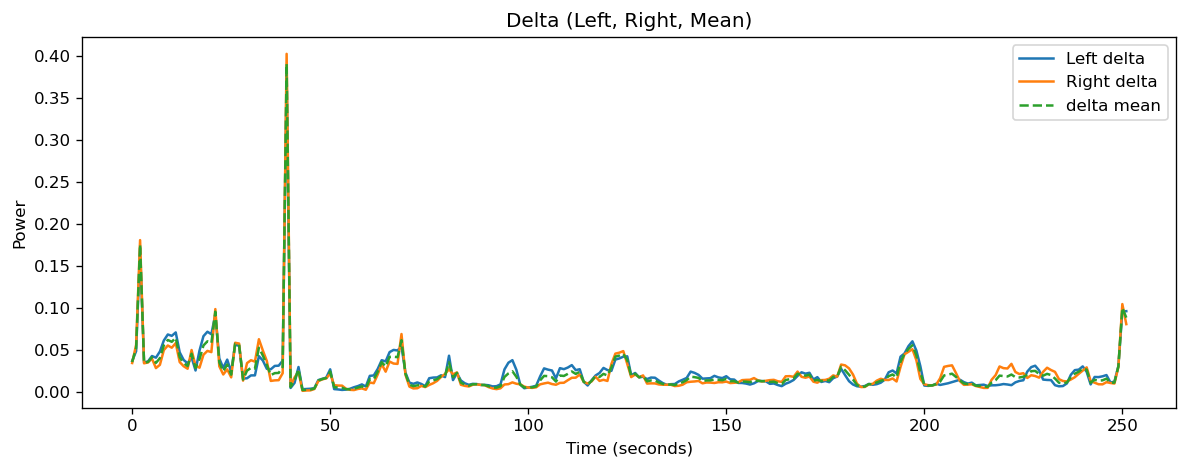

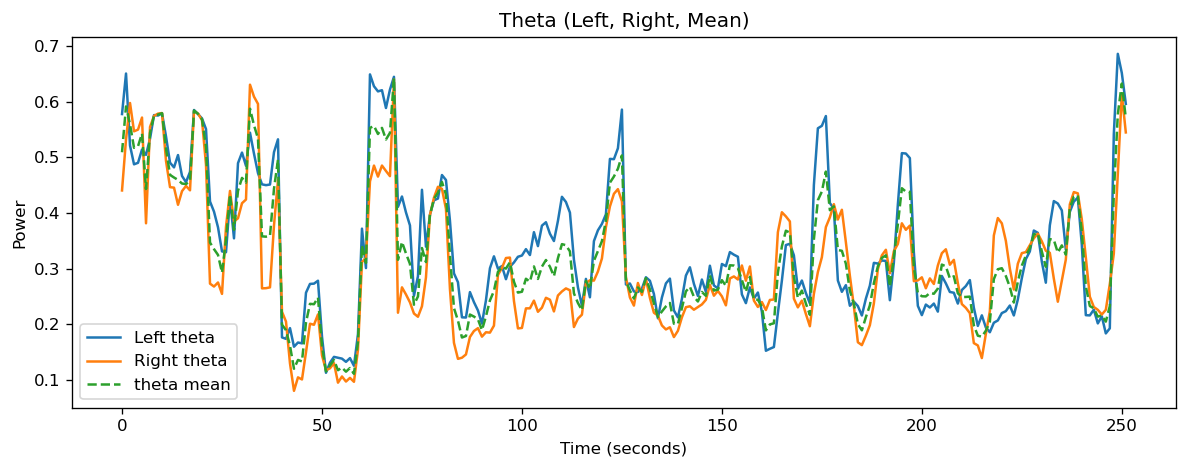

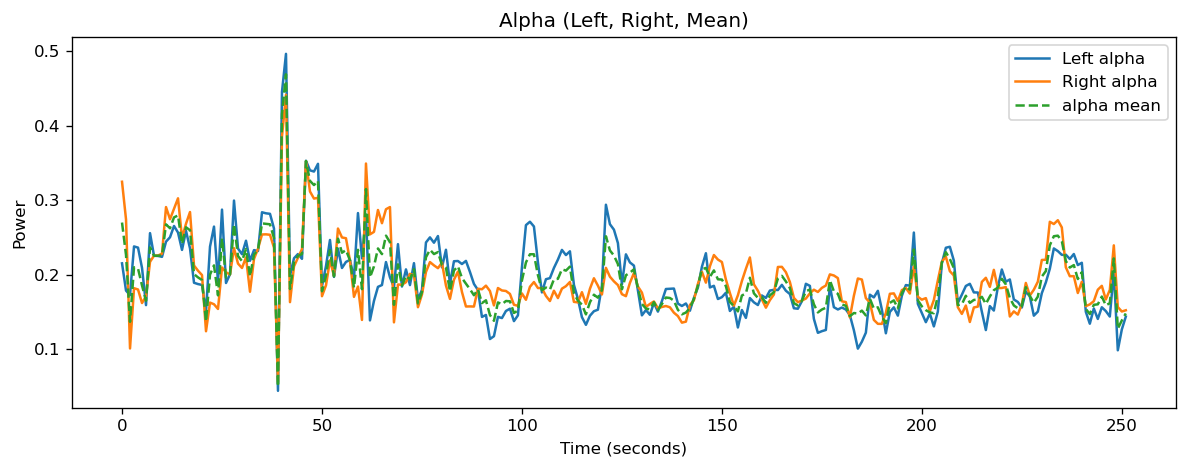

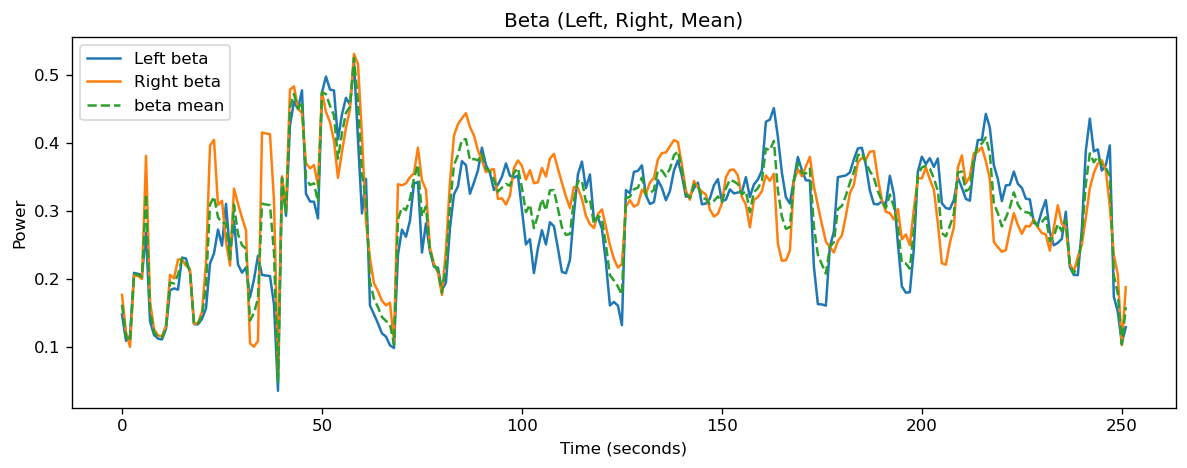

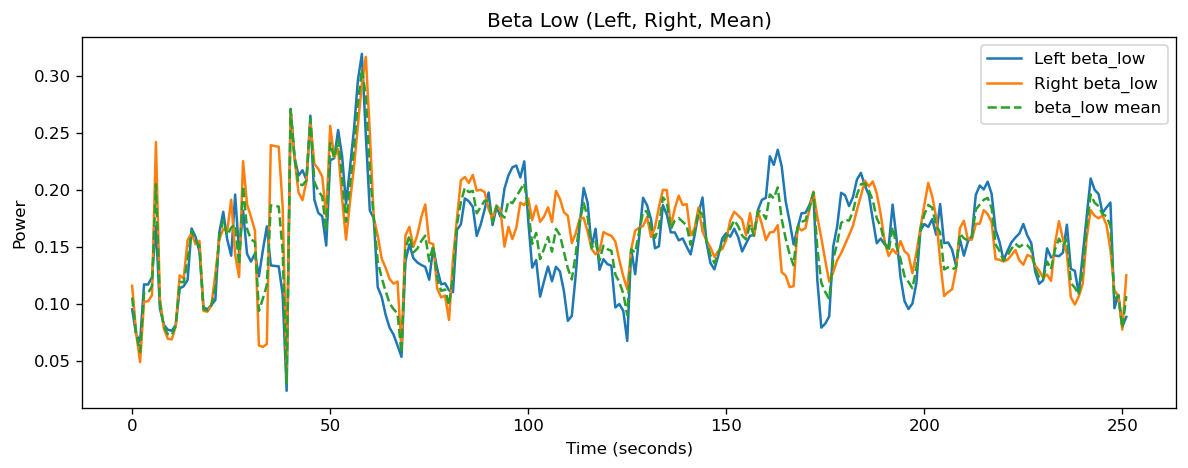

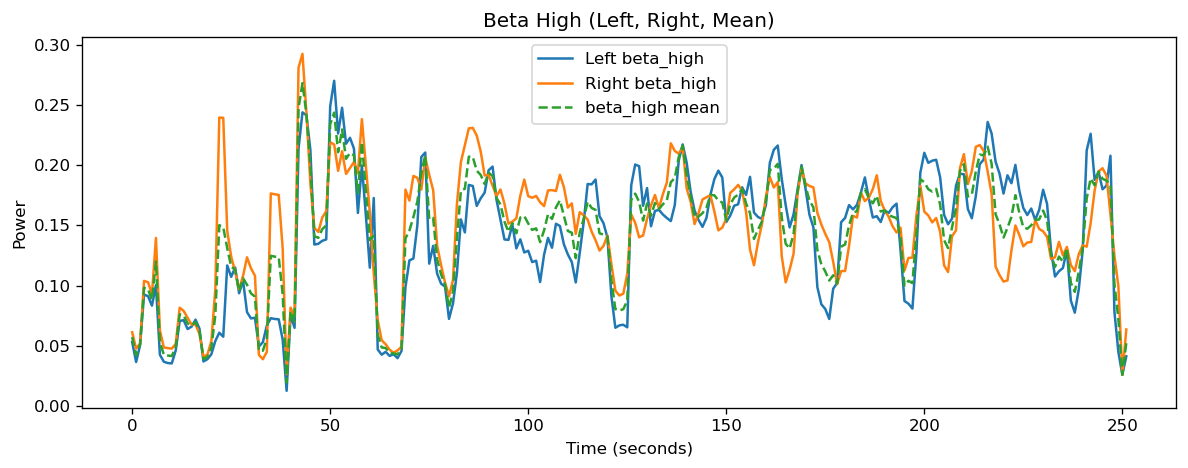

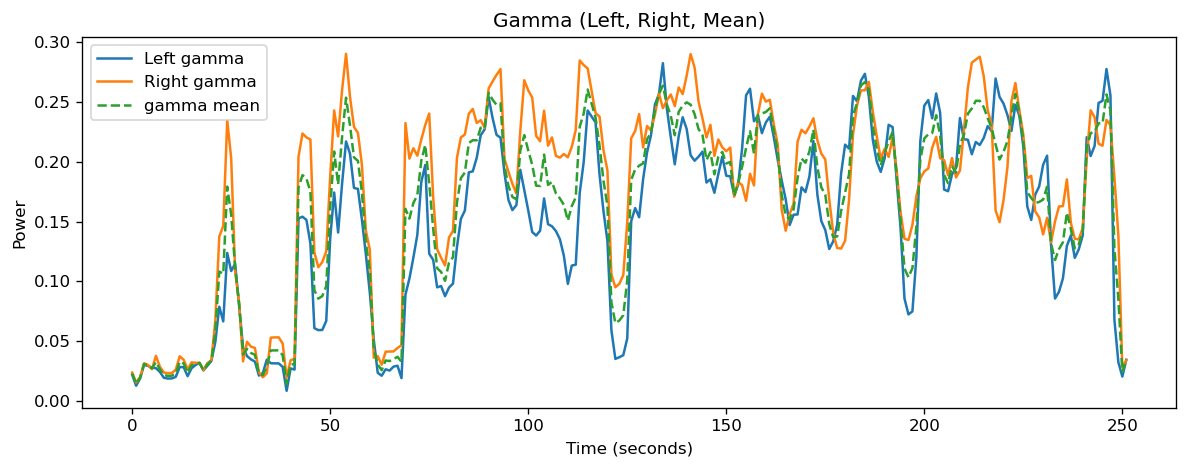

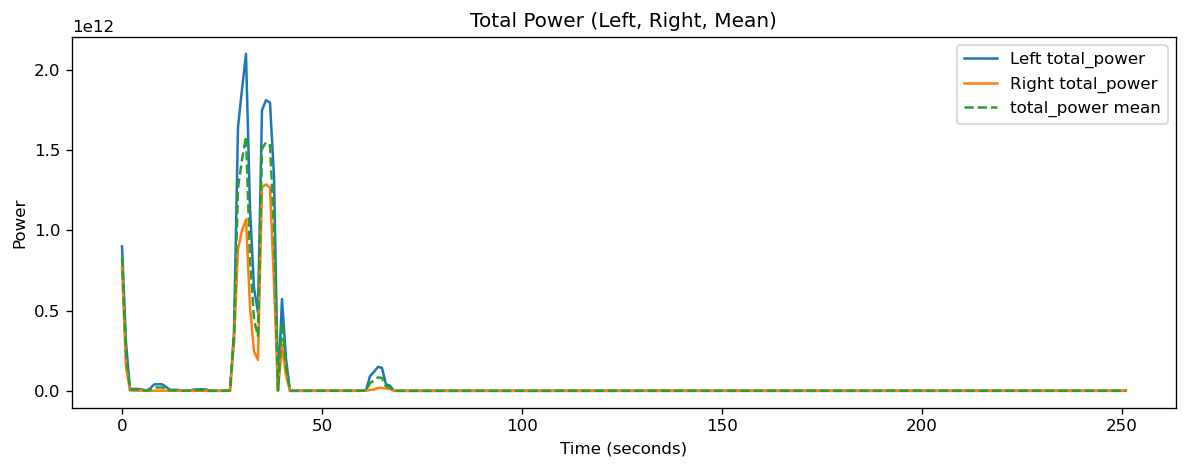

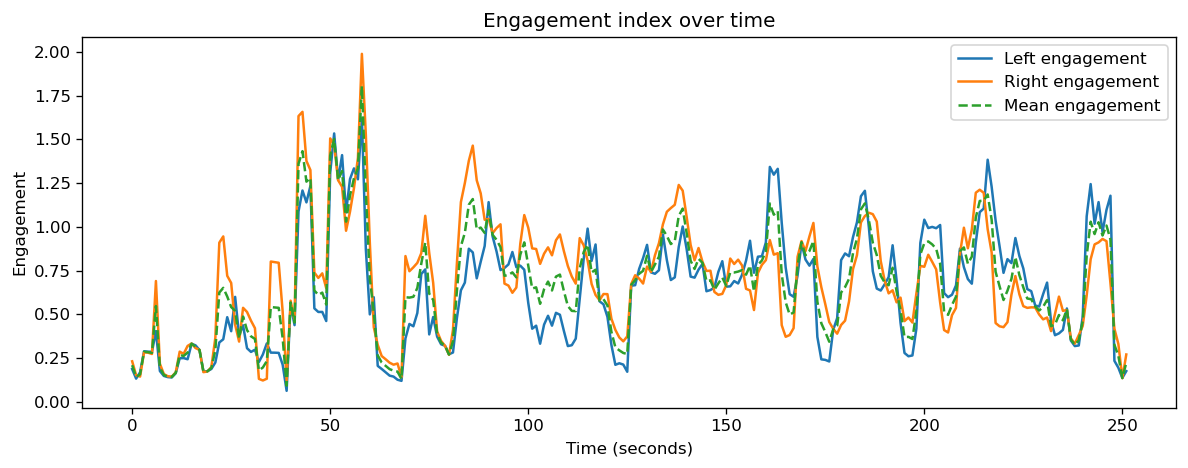

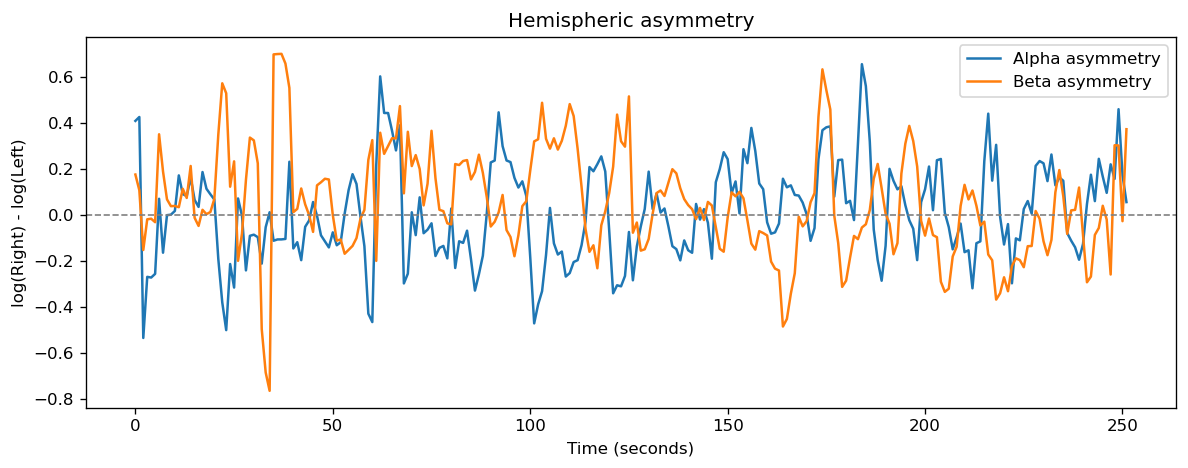

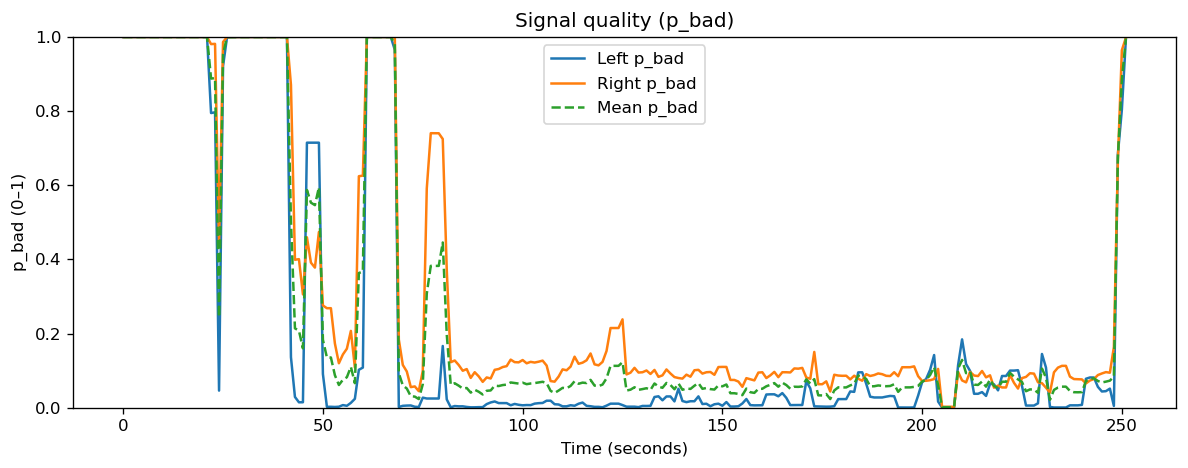

In [37]:
# Optionally choose a directory to save PNGs (set to None to skip saving)
save_dir = Path("eeg_plots")

plot_basic_bands(df, save_dir=save_dir)
plot_engagement_features(df, save_dir=save_dir)


In [38]:
def clean_by_pbad(
    df: pd.DataFrame,
    pbad_col: str = "p_bad_mean",
    threshold: float = 0.2,
    expand: int = 1,
) -> pd.DataFrame:
    """
    Return a cleaned copy of df where:
      - Samples with p_bad_mean > threshold are marked as bad.
      - The bad mask is expanded by `expand` samples on each side.
      - All numeric feature columns (except p_bad*) are set to NaN at bad samples.
      - Those NaNs are filled via time-based linear interpolation + ffill/bfill.

    Assumes df has a DateTimeIndex so method='time' works.
    """

    cleaned = df.copy()

    if pbad_col not in cleaned.columns:
        raise ValueError(f"{pbad_col} not found in dataframe columns.")

    # 1) Base mask: where mean p_bad is above threshold
    bad_mask = cleaned[pbad_col] > threshold

    # 2) Expand mask around spikes by `expand` samples on both sides
    #    (so we also remove a few neighbors around spikes)
    expanded_mask = bad_mask.copy()
    for shift in range(1, expand + 1):
        expanded_mask |= bad_mask.shift(shift, fill_value=False)
        expanded_mask |= bad_mask.shift(-shift, fill_value=False)

    # 3) Decide which columns to clean:
    #    - all numeric columns
    #    - EXCEPT p_bad columns and the mean p_bad (we keep real quality flags)
    numeric_cols = cleaned.select_dtypes(include="number").columns
    cols_to_exclude = [pbad_col] + [c for c in numeric_cols if c.endswith("p_bad")]
    cols_to_clean = [c for c in numeric_cols if c not in cols_to_exclude]

    # 4) Set those bad samples to NaN for the columns we're cleaning
    cleaned.loc[expanded_mask, cols_to_clean] = np.nan

    # 5) Interpolate linearly in time, then fill any edges
    #    (requires DateTimeIndex on df)
    cleaned[cols_to_clean] = (
        cleaned[cols_to_clean]
        .interpolate(method="time")   # time-aware linear interpolation
        .ffill()                      # if NaNs remain at the start
        .bfill()                      # or at the end
    )

    # p_bad columns remain untouched so you can still see where quality was bad
    # expanded_mask itself can be useful to keep:
    cleaned["is_pbad_cleaned"] = expanded_mask

    return cleaned


In [39]:
df = clean_by_pbad(df, pbad_col="p_bad_mean", threshold=0.2, expand=2)


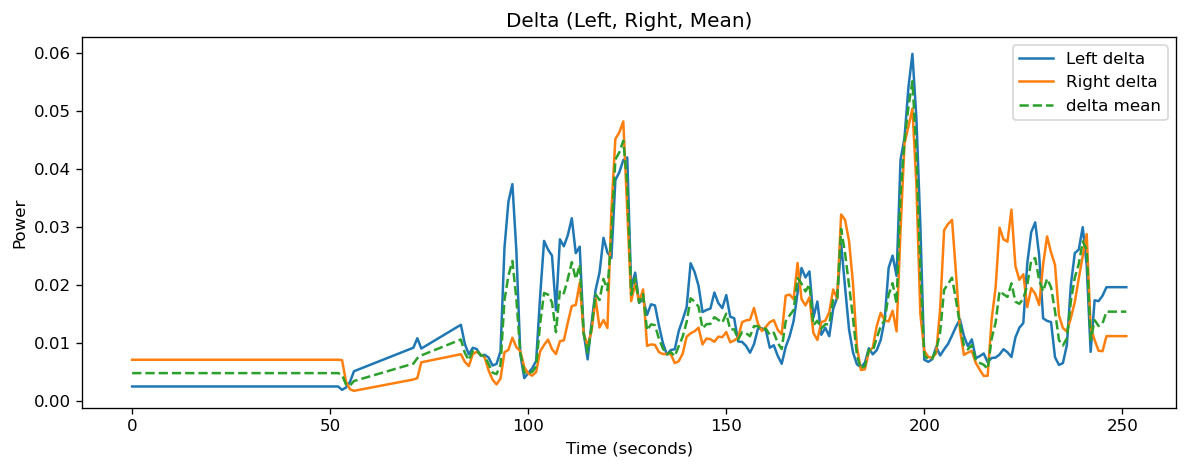

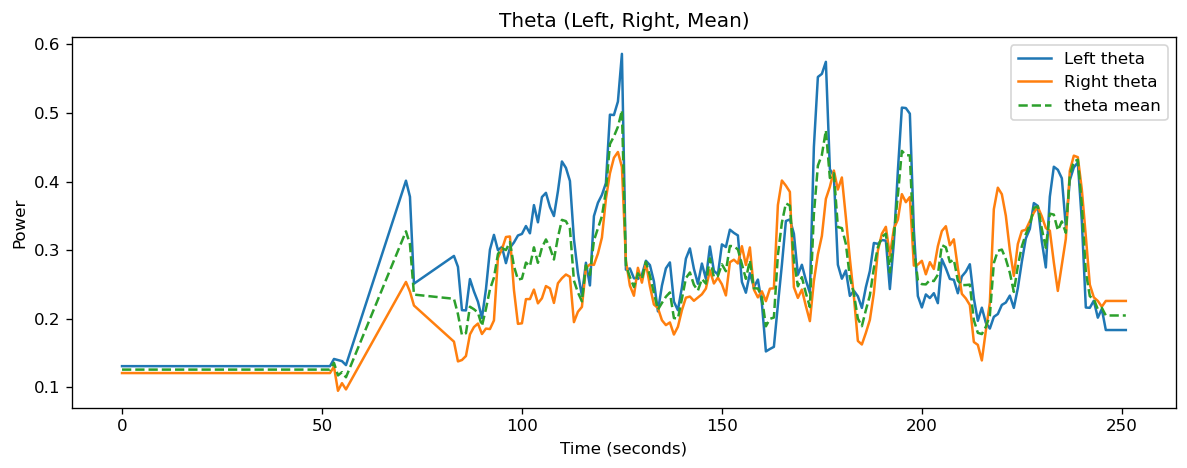

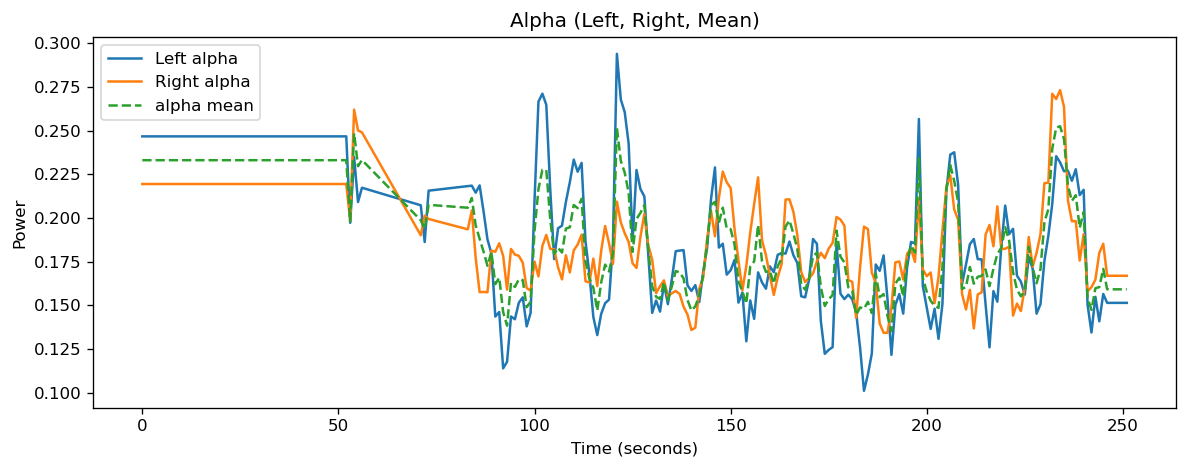

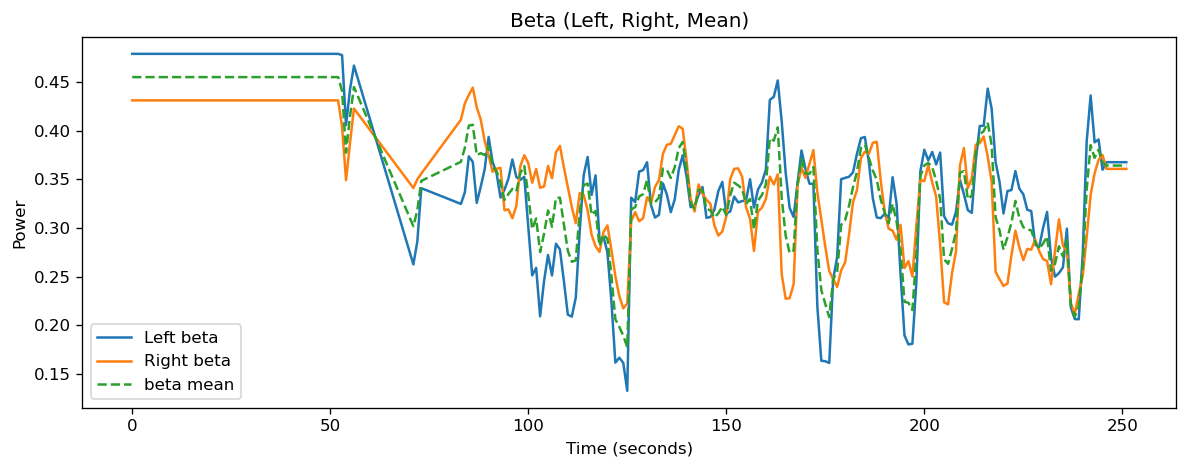

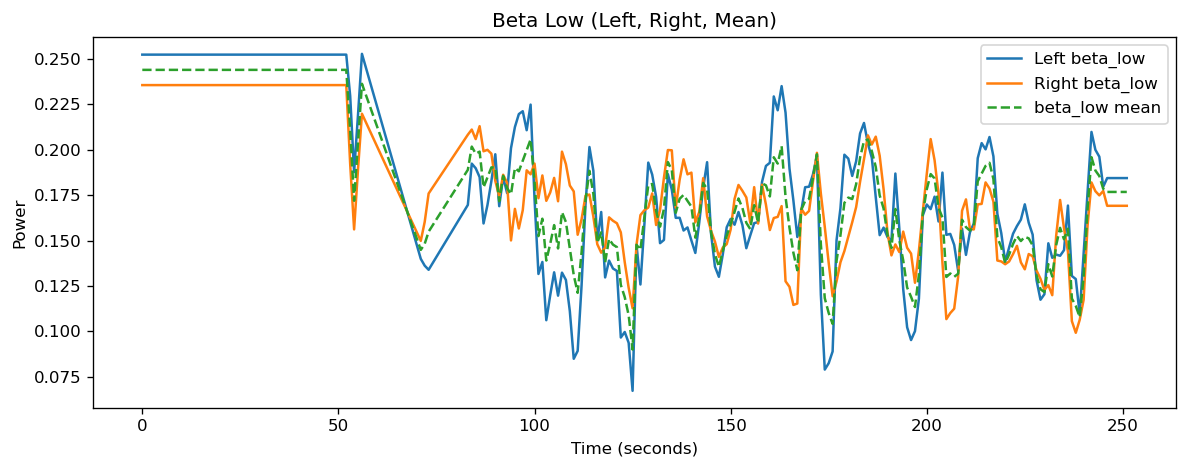

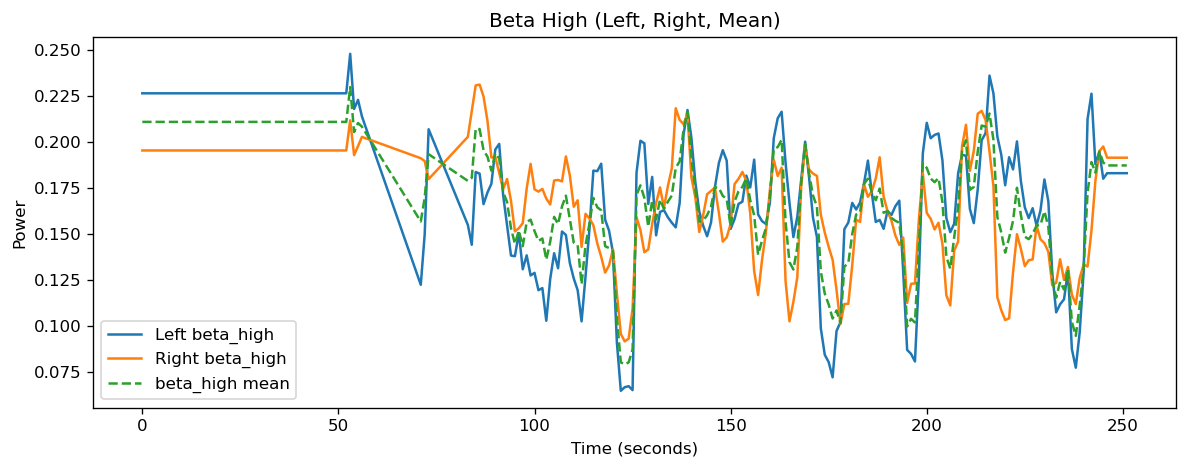

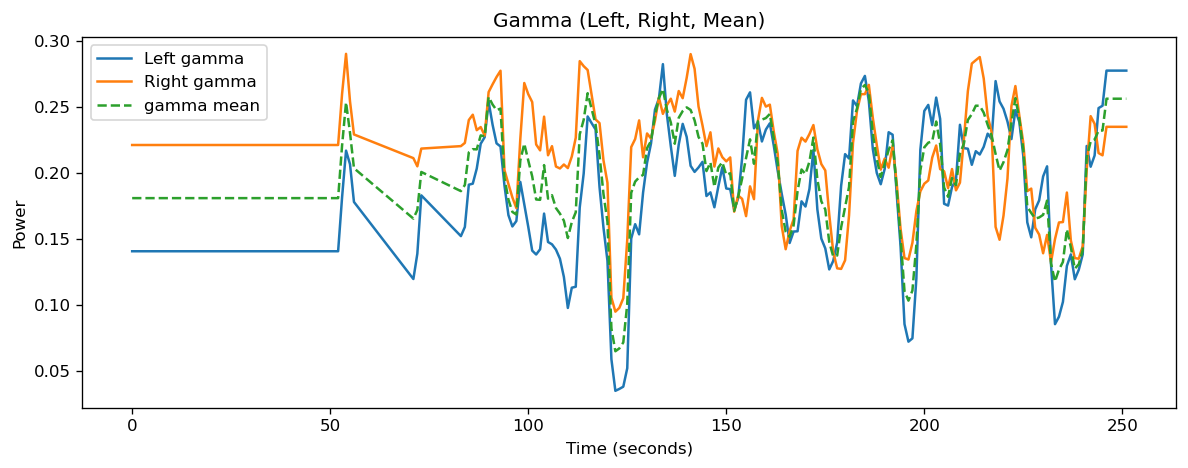

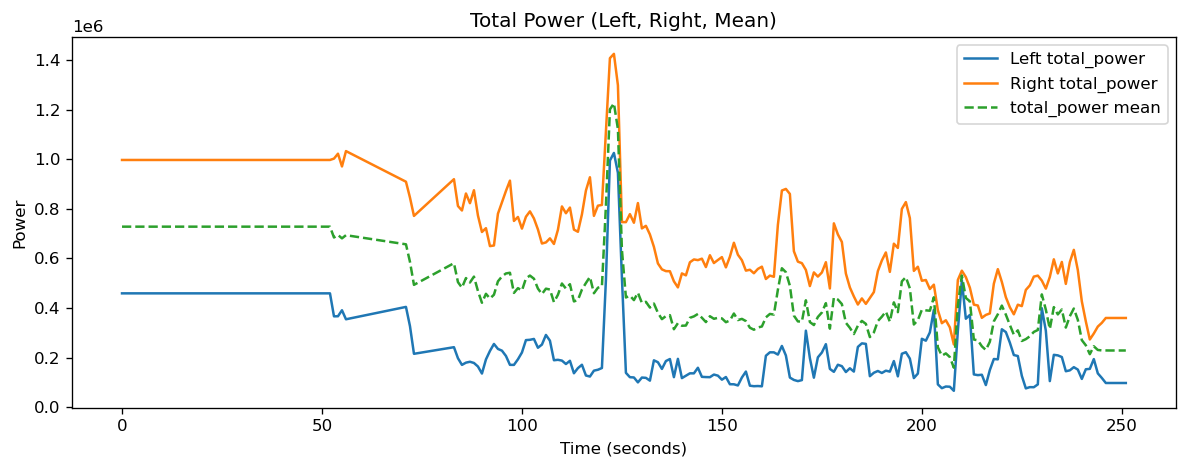

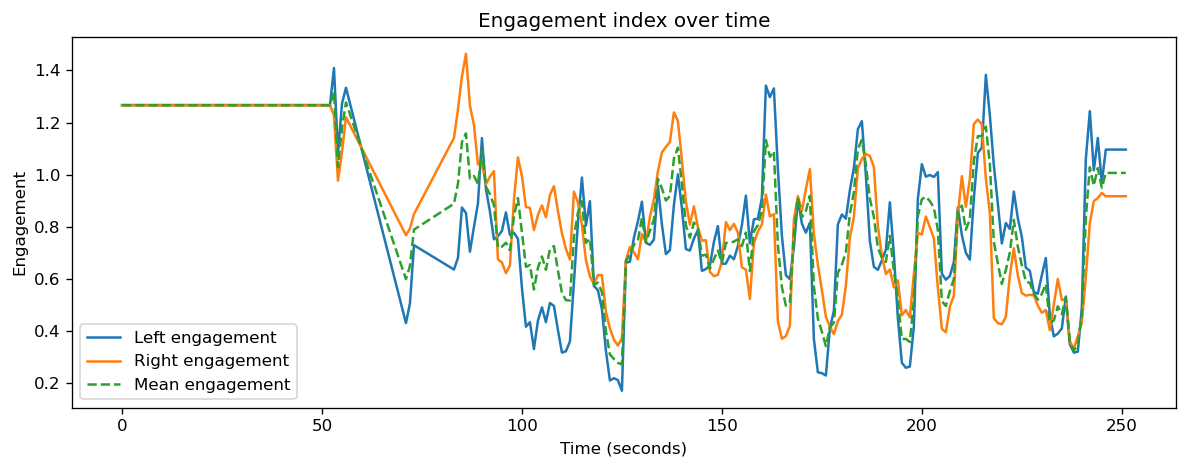

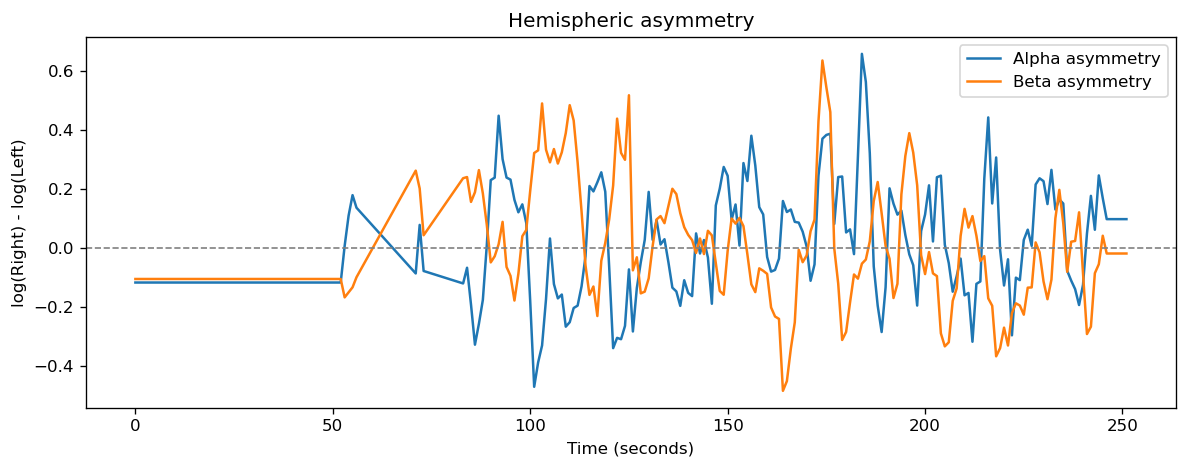

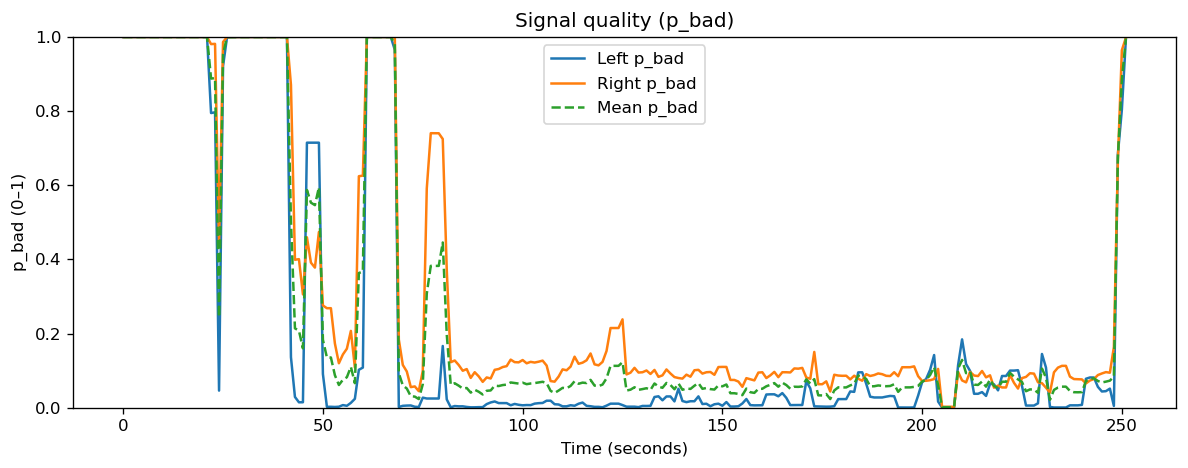

In [40]:
plot_basic_bands(df)
plot_engagement_features(df)



# Data Cleaning

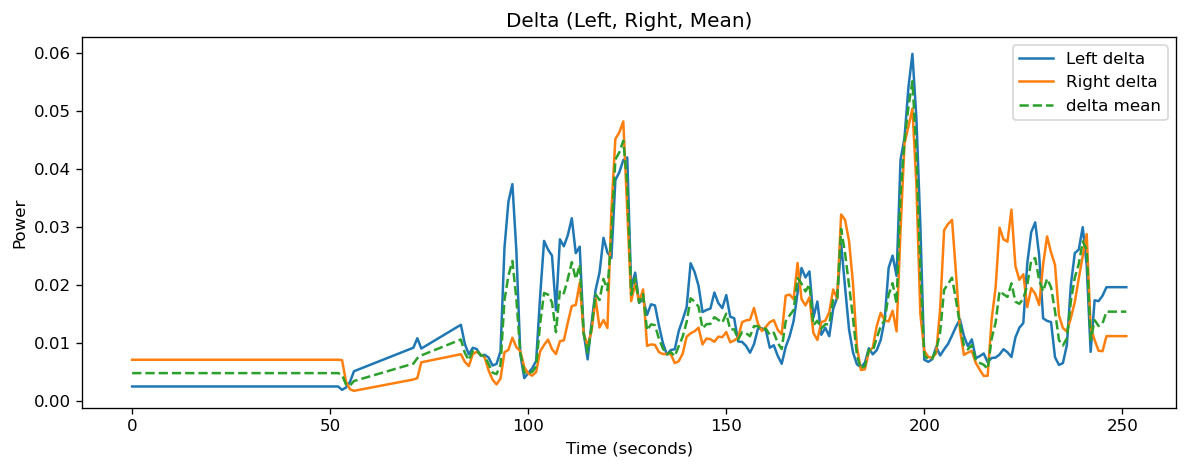

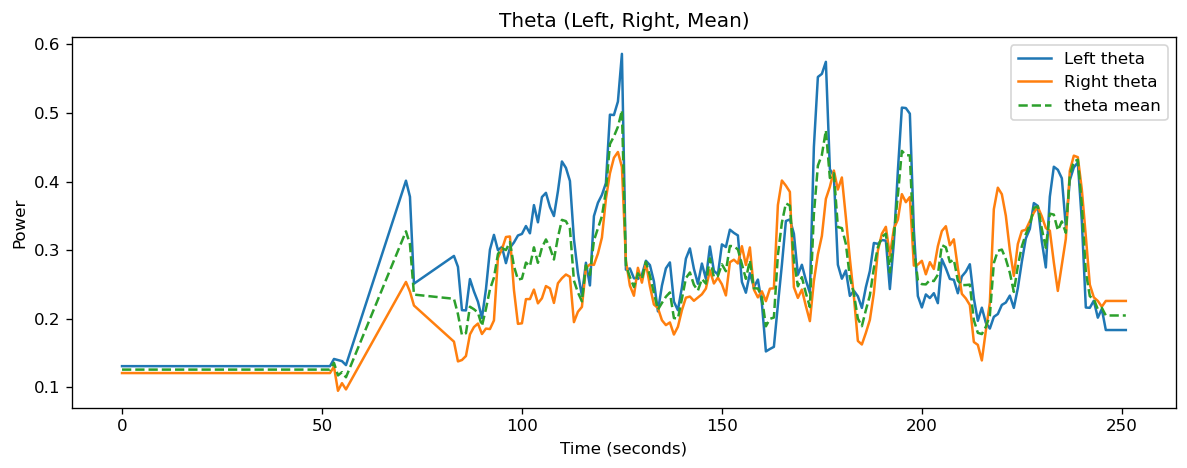

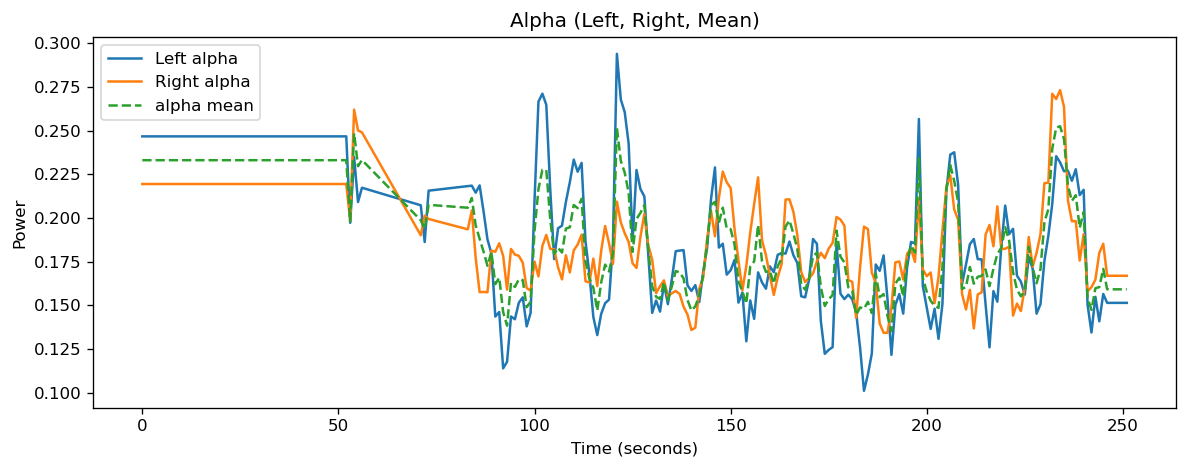

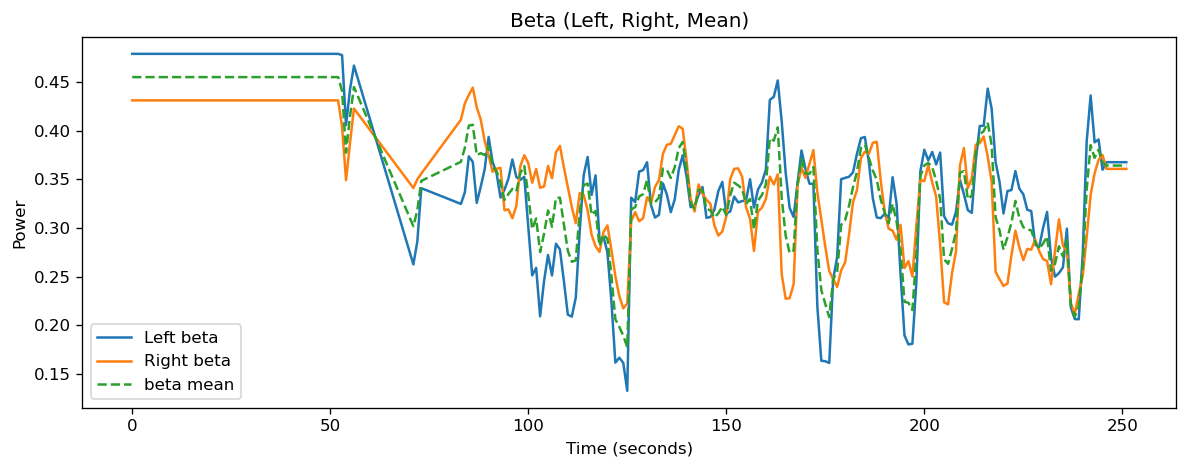

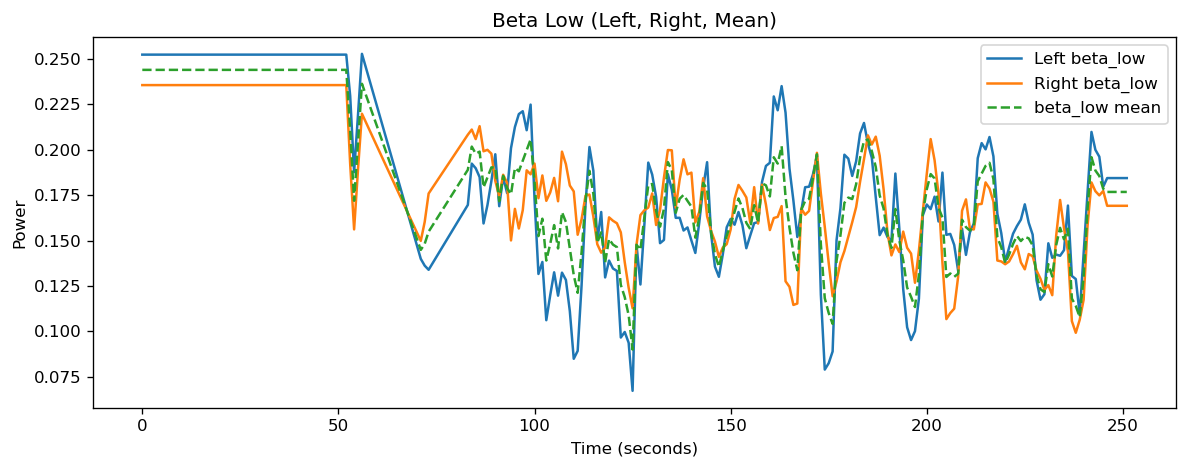

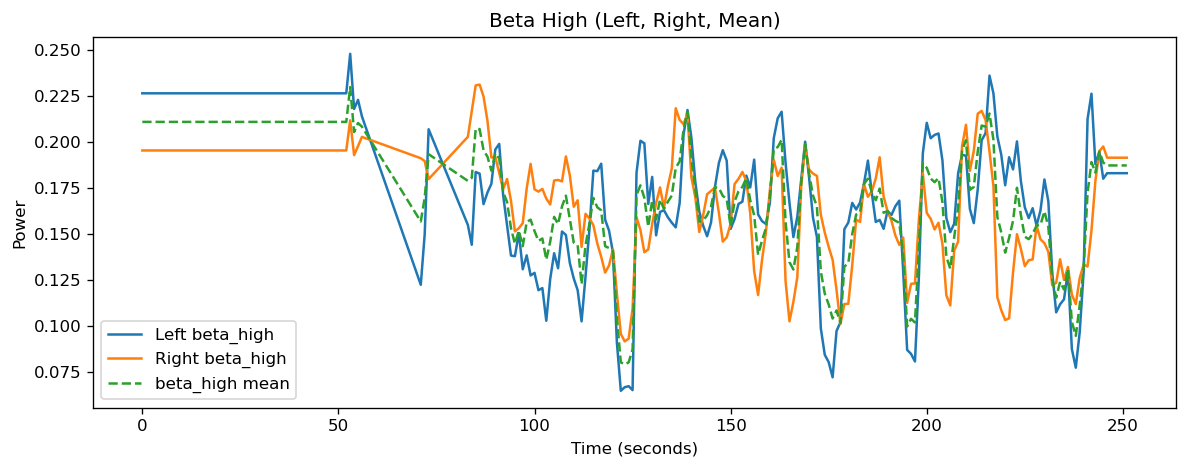

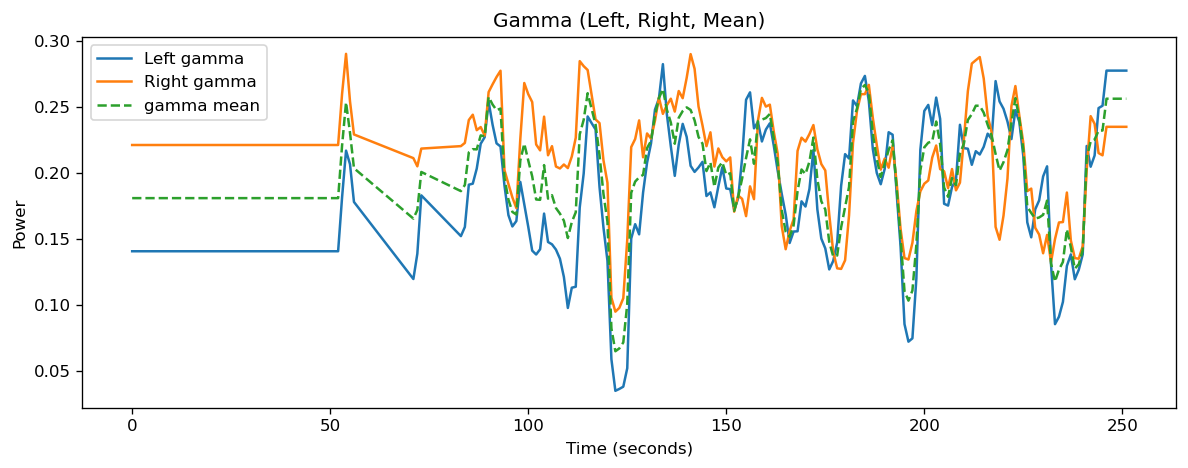

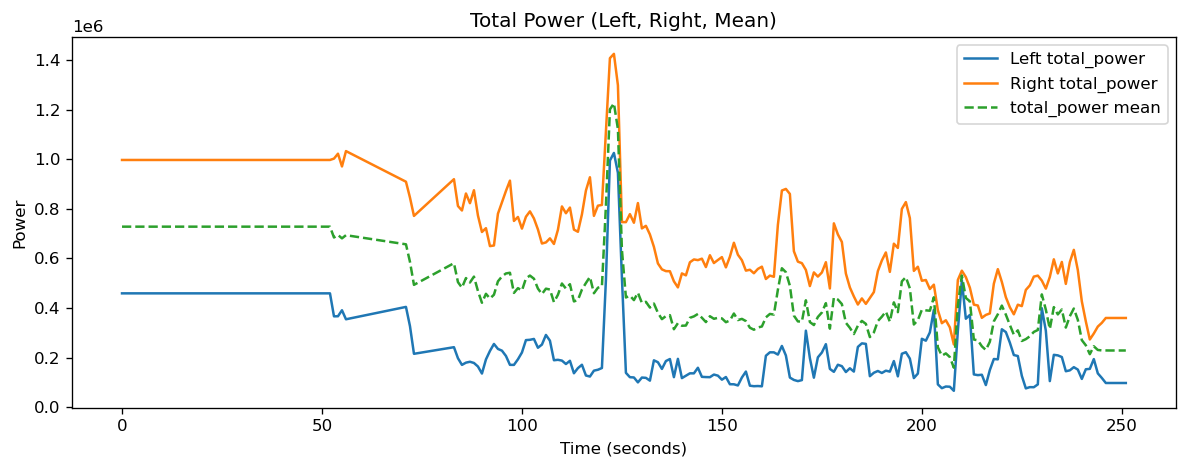

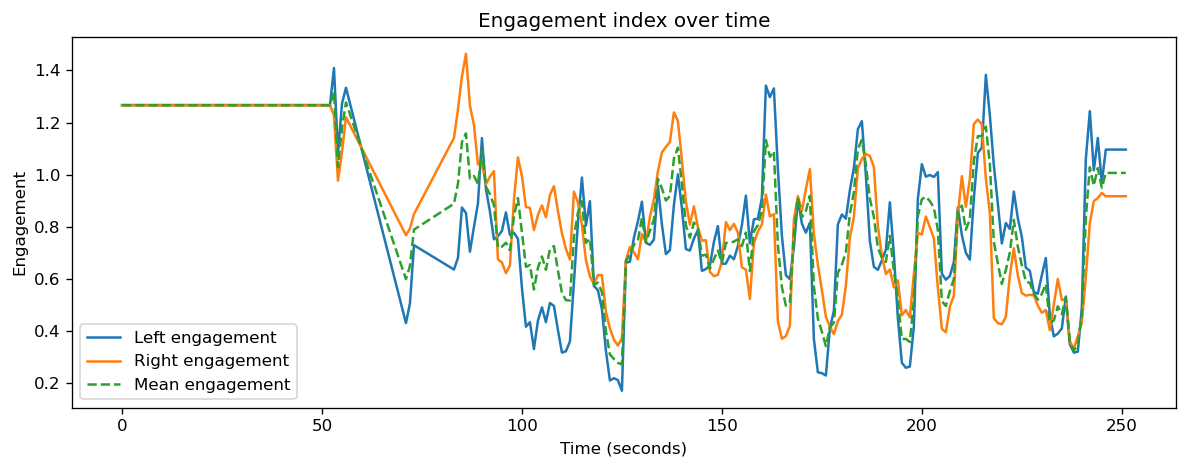

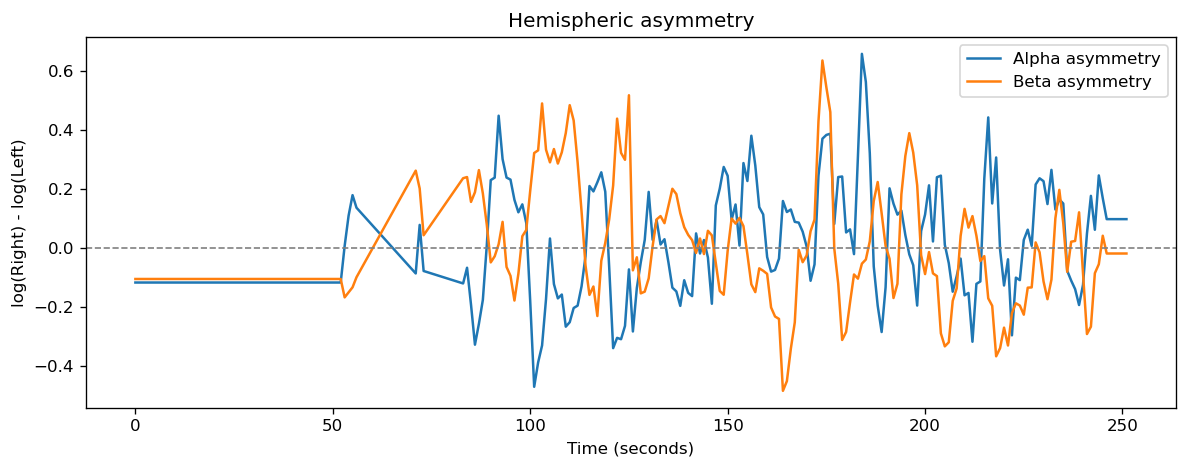

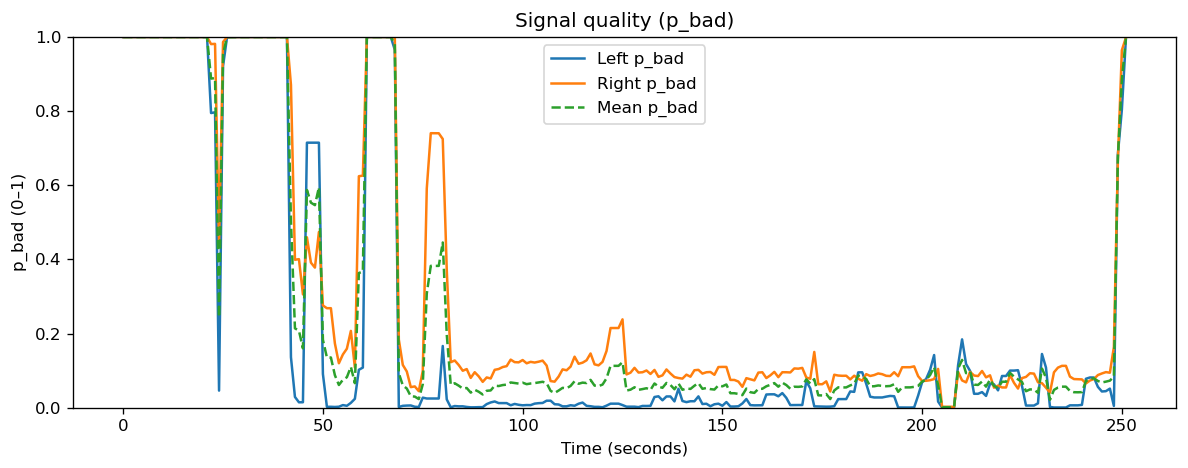

In [41]:
# df already has all features + p_bad and p_bad_mean
df = clean_by_pbad(df, pbad_col="p_bad_mean", threshold=0.5, expand=2)

plot_basic_bands(df)
plot_engagement_features(df)


In [42]:
# Save the DataFrame with engineered features to CSV
output_dir = Path("eeg_out")
output_dir.mkdir(parents=True, exist_ok=True)

csv_path = output_dir / "eeg_with_features.csv"
df.to_csv(csv_path)
print(f"Saved dataframe with engineered features to {csv_path}")


Saved dataframe with engineered features to eeg_out\eeg_with_features.csv


# Music generation with Lyria

In [52]:
df.columns


Index(['Left__total_power', 'Left__delta', 'Left__theta', 'Left__alpha',
       'Left__beta', 'Left__beta_low', 'Left__beta_high', 'Left__gamma',
       'Left__a_ta', 'Left__b_tb', 'Left__b_ab', 'Left__mab_tmab',
       'Left__p_bad', 'Right__total_power', 'Right__delta', 'Right__theta',
       'Right__alpha', 'Right__beta', 'Right__beta_low', 'Right__beta_high',
       'Right__gamma', 'Right__a_ta', 'Right__b_tb', 'Right__b_ab',
       'Right__mab_tmab', 'Right__p_bad', 'time', 'Left__engagement',
       'Left__relaxation', 'Left__theta_beta_ratio',
       'Left__activation_fast_slow', 'Right__engagement', 'Right__relaxation',
       'Right__theta_beta_ratio', 'Right__activation_fast_slow',
       'Alpha_asymmetry', 'Beta_asymmetry', 'Engagement_mean', 'p_bad_mean',
       'is_pbad_cleaned'],
      dtype='object')

In [ ]:
import asyncio
import wave
from google import genai
from google.genai import types
import pandas as pd
import numpy as np
from IPython.display import Audio, display

# --- FIX IS HERE: Pass the api_key explicitly ---
# Replace "YOUR_API_KEY_HERE" with your actual string key
client = genai.Client(
    api_key="API_KEY", # <-- your real API key here API_KEY
    http_options={'api_version': 'v1alpha'}
)

async def eeg_to_lyria_with_recording(df: pd.DataFrame, step_duration=1.0, filename="my_brain_music.wav"):
    
    full_audio_buffer = bytearray()
    
    # 1. Background Listener
    async def receive_audio(session):
        try:
            while True:
                async for message in session.receive():
                    if message.server_content and message.server_content.audio_chunks:
                        chunk = message.server_content.audio_chunks[0].data
                        full_audio_buffer.extend(chunk)
        except asyncio.CancelledError:
            # This allows the task to stop cleanly when we tell it to
            print("\nStream finished. Stopping listener...")
            pass

    print(f"Connecting to Lyria... (Recording to {filename})")

    async with (
        client.aio.live.music.connect(model='models/lyria-realtime-exp') as session,
        asyncio.TaskGroup() as tg,
    ):
        # FIX: Capture the task object so we can stop it later
        listener_task = tg.create_task(receive_audio(session))
        
        await session.play()
        last_bpm = 0

        # 2. Main Loop
        # We use 'reset_index' so 'i' is always 0,1,2... relative to this run
        for i, (_, row) in enumerate(df.iterrows()):
            
            eng = row.get('Engagement_mean')
            relaxL = row.get('Left__relaxation', 1.0)
            relaxR = row.get('Right__relaxation', 1.0)
            relax = (relaxL + relaxR) / 2.0
            attL = row.get('Left__attention', 1.0)
            attR = row.get('Right__attention', 1.0)
            att = (attL + attR) / 2.0
            
            weight_energy = np.clip(eng, 0.1, 2.0)
            weight_calm = np.clip(relax, 0.1, 2.0)
            target_bpm = int(80 + (eng * 60))
            target_density = np.clip(att, 0.2, 0.9)

            print(f"[{i}/{len(df)}] Rec... Eng={eng:.2f} BPM={target_bpm}")

            # Send Prompts
            await session.set_weighted_prompts(
                prompts=[
                    types.WeightedPrompt(text="Deep techno, driving beat, energetic", weight=float(weight_energy)),
                    types.WeightedPrompt(text="Ambient meditation, soft piano", weight=float(weight_calm)),
                ]
            )

            # Send Config
            should_reset = abs(target_bpm - last_bpm) > 5
            await session.set_music_generation_config(
                config=types.LiveMusicGenerationConfig(
                    bpm=target_bpm,
                    density=float(target_density),
                    scale=types.Scale.C_MAJOR_A_MINOR, 
                )
            )
            
            if should_reset and last_bpm != 0:
                await session.reset_context()
            
            last_bpm = target_bpm
            await asyncio.sleep(step_duration)

        # FIX: Once loop is done, CANCEL the background listener
        # This releases the TaskGroup and lets the code proceed to save
        listener_task.cancel()

    # 3. Save to WAV File
    if len(full_audio_buffer) == 0:
        print("Warning: No audio data received! (Did the connection fail?)")
        return

    print(f"\nSession complete. Saving {len(full_audio_buffer)} bytes to {filename}...")
    
    with wave.open(filename, "wb") as wf:
        wf.setnchannels(2)     
        wf.setsampwidth(2)     
        wf.setframerate(48000) 
        wf.writeframes(full_audio_buffer)
        
    print("Saved!")
    return display(Audio(filename))


In [56]:
await eeg_to_lyria_with_recording(df.tail(20), step_duration=1.0, filename="brain_music_test.wav")


Connecting to Lyria... (Recording to brain_music_test.wav)
[0/20] Rec... Eng=0.43 BPM=105
[1/20] Rec... Eng=0.44 BPM=106
[2/20] Rec... Eng=0.50 BPM=109
[3/20] Rec... Eng=0.47 BPM=107
[4/20] Rec... Eng=0.53 BPM=111
[5/20] Rec... Eng=0.36 BPM=101
[6/20] Rec... Eng=0.33 BPM=99
[7/20] Rec... Eng=0.35 BPM=101
[8/20] Rec... Eng=0.46 BPM=107
[9/20] Rec... Eng=0.83 BPM=130
[10/20] Rec... Eng=1.03 BPM=141
[11/20] Rec... Eng=0.96 BPM=137
[12/20] Rec... Eng=1.03 BPM=141
[13/20] Rec... Eng=0.95 BPM=137
[14/20] Rec... Eng=1.01 BPM=140
[15/20] Rec... Eng=1.01 BPM=140
[16/20] Rec... Eng=1.01 BPM=140
[17/20] Rec... Eng=1.01 BPM=140
[18/20] Rec... Eng=1.01 BPM=140
[19/20] Rec... Eng=1.01 BPM=140

Stream finished. Stopping listener...

Session complete. Saving 3456000 bytes to brain_music_test.wav...
Saved!
